<a href="https://colab.research.google.com/github/PankajKhanwariya/PankajKhanwariya/blob/main/Project_4_Street_View_Blurring_System_(Kaggle).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import yaml
import cv2
import matplotlib.pyplot as plt

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/pankajkhanwariya5
/kaggle/input/datasets/pankajkhanwariya5/image-data
/kaggle/input/datasets/pankajkhanwariya5/image-data/labels_zipped
/kaggle/input/datasets/pankajkhanwariya5/image-data/labels_zipped/labels
/kaggle/input/datasets/pankajkhanwariya5/image-data/labels_zipped/labels/val
/kaggle/input/datasets/pankajkhanwariya5/image-data/labels_zipped/labels/test
/kaggle/input/datasets/pankajkhanwariya5/image-data/labels_zipped/labels/train
/kaggle/input/datasets/pankajkhanwariya5/image-data/images_zipped
/kaggle/input/datasets/pankajkhanwariya5/image-data/images_zipped/images
/kaggle/input/datasets/pankajkhanwariya5/image-data/images_zipped/images/val
/kaggle/input/datasets/pankajkhanwariya5/image-data/images_zipped/images/test
/kaggle/input/datasets/pankajkhanwariya5/image-data/images_zipped/images/train


In [ ]:
from glob import glob

BASE_DIR = "/kaggle/input/datasets/pankajkhanwariya5/image-data"

In [ ]:
# Image paths
train_images = sorted(glob(f"{BASE_DIR}/images_zipped/images/train/*.jpg"))
val_images   = sorted(glob(f"{BASE_DIR}/images_zipped/images/val/*.jpg"))
test_images  = sorted(glob(f"{BASE_DIR}/images_zipped/images/test/*.jpg"))

# Label paths
train_labels = sorted(glob(f"{BASE_DIR}/labels_zipped/labels/train/*.txt"))
val_labels   = sorted(glob(f"{BASE_DIR}/labels_zipped/labels/val/*.txt"))
test_labels  = sorted(glob(f"{BASE_DIR}/labels_zipped/labels/test/*.txt"))

In [ ]:
# Missing and mismatched data report
import os

image_names = {
    os.path.splitext(os.path.basename(f))[0]
    for f in train_images
}

label_names = {
    os.path.splitext(os.path.basename(f))[0]
    for f in train_labels
}

print("Missing Images:", len(label_names - image_names))
print("Missing Labels:", len(image_names - label_names))

Missing Images: 2127
Missing Labels: 138


In [ ]:
# Cleaning data and syncing the image and corresponding annotation data
import os
from glob import glob

image_dir = "/kaggle/input/datasets/pankajkhanwariya5/image-data/images_zipped/images/train"
label_dir = "/kaggle/input/datasets/pankajkhanwariya5/image-data/labels_zipped/labels/train"

image_names = {
    os.path.splitext(os.path.basename(f))[0]
    for f in glob(image_dir + "/*.jpg")
}

label_names = {
    os.path.splitext(os.path.basename(f))[0]
    for f in glob(label_dir + "/*.txt")
}

common = image_names & label_names

train_images = sorted([os.path.join(image_dir, f + ".jpg") for f in common])
train_labels = sorted([os.path.join(label_dir, f + ".txt") for f in common])

print("Matched Images :", len(train_images))
print("Matched Labels :", len(train_labels))

Matched Images : 23545
Matched Labels : 23545


In [ ]:
# Final data
print(len(train_images), len(train_labels))
print(len(val_images), len(val_labels))
print(len(test_images), len(test_labels))

23545 23545
1073 1073
386 386


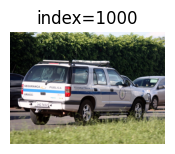

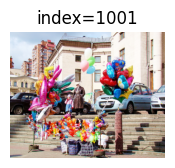

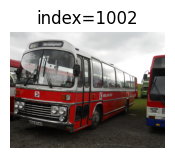

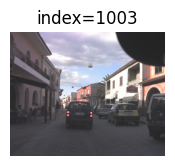

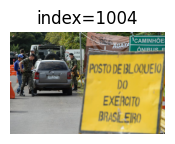

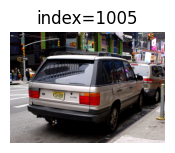

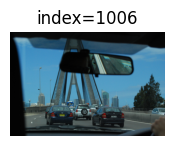

In [ ]:
# Checking images and corresponding labels
for i in range(1000,1007):
  plt.figure(figsize=(2,2))
  img = plt.imread(train_images[i])
  plt.imshow(img)
  plt.title(f'index={i}')
  plt.axis("off")

In [ ]:
with open(train_labels[0], "r") as f:
    print(f.read()) # class id, center of the box x, center of the box y, width of the box, height of the box

0 0.1083989375 0.40522884313725493 0.04687400000000001 0.03921599999999997
0 0.751953375 0.709967705882353 0.04427099999999995 0.07516299999999994



Above label representing like this :

Class = 0

Center X = 0.6370192307692307

Center Y = 0.2247596153846154

Width = 0.18028846153846154

Height = 0.27403846153846156

In [ ]:
train_labels[:5]
#print(train_images[:5])

['/kaggle/input/datasets/pankajkhanwariya5/image-data/labels_zipped/labels/train/3acddfb2b87642ec.txt',
 '/kaggle/input/datasets/pankajkhanwariya5/image-data/labels_zipped/labels/train/3af34a6337f3ff1e.txt',
 '/kaggle/input/datasets/pankajkhanwariya5/image-data/labels_zipped/labels/train/3b3e5235ea33c327.txt',
 '/kaggle/input/datasets/pankajkhanwariya5/image-data/labels_zipped/labels/train/3b53976a94e33073.txt',
 '/kaggle/input/datasets/pankajkhanwariya5/image-data/labels_zipped/labels/train/3b63f4fffb591402.txt']

In [ ]:
train_images[:5]

['/kaggle/input/datasets/pankajkhanwariya5/image-data/images_zipped/images/train/3acddfb2b87642ec.jpg',
 '/kaggle/input/datasets/pankajkhanwariya5/image-data/images_zipped/images/train/3af34a6337f3ff1e.jpg',
 '/kaggle/input/datasets/pankajkhanwariya5/image-data/images_zipped/images/train/3b3e5235ea33c327.jpg',
 '/kaggle/input/datasets/pankajkhanwariya5/image-data/images_zipped/images/train/3b53976a94e33073.jpg',
 '/kaggle/input/datasets/pankajkhanwariya5/image-data/images_zipped/images/train/3b63f4fffb591402.jpg']

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.7 MB/s eta 0:00:00a 0:00:01


In [ ]:
from glob import glob
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Read image dimensions
image_path = train_images[1006] #9
img = cv2.imread(image_path)

image_path2 = train_images[9] #9
img2 = cv2.imread(image_path2)

h, w, c = img.shape
h2, w2, c2 = img2.shape

print(h, w, c)
print(h2, w2, c2)

685 1024 3
1024 768 3


(np.float64(-0.5), np.float64(1023.5), np.float64(684.5), np.float64(-0.5))

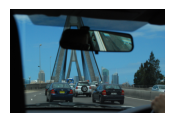

In [ ]:
img = plt.imread(train_images[1006])
plt.figure(figsize=(2,2))
plt.imshow(img)
plt.axis("off")

In [ ]:
image_path

'/kaggle/input/datasets/pankajkhanwariya5/image-data/images_zipped/images/train/7c4415f7c9ba5085.jpg'

In [ ]:
# Read YOLO annotation
label_path = image_path.replace("/images/", "/labels/").replace("/images_zipped/", "/labels_zipped/").replace(".jpg", ".txt") # reading here the same label that corresponds to same image

with open(label_path) as f:
    label = f.readline().strip()

print(label)

0 0.3353515625 0.8010689781021898 0.03375 0.021474999999999998


In [ ]:
class_id, x, y, bw, bh = map(float, label.split())

print(class_id, x, y, bw, bh)

0.0 0.3353515625 0.8010689781021898 0.03375 0.021474999999999998


In [ ]:
# Converting annotattions to pixel
X = x * w
Y = y * h

Bw = bw * w
Bh = bh * h

In [ ]:
# convrting 'Center' to 'Corner' coordinates
x1 = int(X - Bw/2)
y1 = int(Y - Bh/2)

x2 = int(X + Bw/2)
y2 = int(Y + Bh/2)

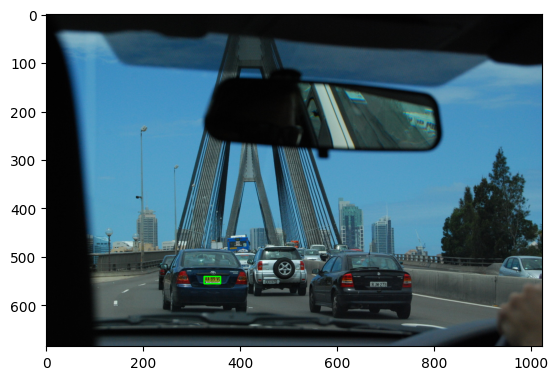

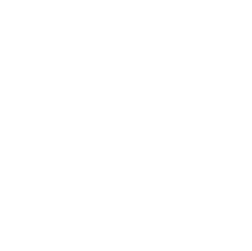

In [ ]:
# Draw 'Bounding' box
img = cv2.imread(train_images[1006])

cv2.rectangle(img,
              (x1, y1),
              (x2, y2),
              (0,255,0),
              2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.figure(figsize=(3,3))
plt.axis("off")
plt.show()

In [ ]:
from ultralytics import YOLO

In [ ]:
%%writefile data.yaml
path: /kaggle/working/dataset

train: images/train
val: images/val
test: images/test

names:
  0: license_plate

Writing data.yaml


In [ ]:
# Load pretrained YOLOv8

model = YOLO("yolov8n.pt")

In [ ]:
import os
import shutil
from pathlib import Path

# Paths to raw Kaggle input
BASE_INPUT = Path("/kaggle/input/datasets/pankajkhanwariya5/image-data")
SRC_IMG = BASE_INPUT / "images_zipped/images"
SRC_LBL = BASE_INPUT / "labels_zipped/labels"

# Working directory
DEST = Path("/kaggle/working/dataset")

# Reset directory if previously created
if DEST.exists():
    shutil.rmtree(DEST)

def sync_and_copy_split(split):
    img_dir = SRC_IMG / split
    lbl_dir = SRC_LBL / split

    out_img = DEST / "images" / split
    out_lbl = DEST / "labels" / split
    out_img.mkdir(parents=True, exist_ok=True)
    out_lbl.mkdir(parents=True, exist_ok=True)

    # Map filenames by stem (without extension)
    images = {f.stem: f for f in img_dir.glob("*.jpg")}
    labels = {f.stem: f for f in lbl_dir.glob("*.txt")}

    # Exact intersection of matched files
    common_stems = set(images.keys()) & set(labels.keys())
    print(f"[{split.upper()}] Copying {len(common_stems)} matched image-label pairs...")

    for stem in common_stems:
        shutil.copy(images[stem], out_img / images[stem].name)
        shutil.copy(labels[stem], out_lbl / labels[stem].name)

# Copy all splits
for split in ["train", "val", "test"]:
    sync_and_copy_split(split)

print("\nDataset successfully prepared and synced at /kaggle/working/dataset!")

[TRAIN] Copying 23545 matched image-label pairs...
[VAL] Copying 1073 matched image-label pairs...
[TEST] Copying 386 matched image-label pairs...

Dataset successfully prepared and synced at /kaggle/working/dataset!


In [ ]:
yaml_content = """
path: /kaggle/working/dataset

train: images/train
val: images/val
test: images/test

names:
  0: license_plate
"""

with open("data.yaml", "w") as f:
    f.write(yaml_content.strip())

print("data.yaml successfully created!")

data.yaml successfully created!


In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

In [ ]:
results = model.train(
    data="data.yaml",
    epochs=12,
    imgsz=640,
    batch=64,
    workers=2,
    cache=False,
    device=0,
    project="/kaggle/working/YOLO_Project",
    name="Run1",
    patience=5,
    save=True,
    exist_ok=True
)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=12, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Run1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

In [ ]:
from ultralytics import YOLO

# Load the best saved model weights
model = YOLO("/kaggle/working/YOLO_Project/Run1/weights/best.pt")

# Run validation on the TEST split
test_metrics = model.val(data="data.yaml", split="test")

# Print key test metrics
print(f"Test Precision: {test_metrics.box.mp:.3f}")
print(f"Test Recall: {test_metrics.box.mr:.3f}")
print(f"Test mAP50:    {test_metrics.box.map50:.3f}")
print(f"Test mAP50_95:    {test_metrics.box.map:.3f}")

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2566.4±437.0 MB/s, size: 229.6 KB)
val: Scanning /kaggle/working/dataset/labels/test.cache... 386 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 386/386 147.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.4it/s 3.9s0.1s
                   all        386        512      0.923      0.823       0.88      0.617
Speed: 1.1ms preprocess, 3.0ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2
Test Precision: 0.923
Test Recall: 0.823
Test mAP50:    0.880
Test mAP50_95:    0.617


In [ ]:
# 1. Detect objects (Bounding Boxes)
results = model.predict(source=img, conf=0.25)

for result in results:
    for box in result.boxes.xyxy.cpu().numpy():
        # 2. Extract bounding box coordinates as integer pixels
        x1, y1, x2, y2 = map(int, box[:4])

        # 3. Crop the detected region (Region of Interest / ROI)
        roi = img[y1:y2, x1:x2]

        if roi.size > 0:
            # 4. Apply Gaussian Blur and replace the original pixels
            blurred_roi = cv2.GaussianBlur(roi, (51, 51), 30)
            img[y1:y2, x1:x2] = blurred_roi


0: 448x640 2 license_plates, 41.4ms
Speed: 5.4ms preprocess, 41.4ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


In [ ]:
# calculating frame per second
1000 / (5.4 + 41.4 + 1.4)

20.74688796680498

Total Time per Frame: 1000 / (5.4ms + 41.4ms + 1.4ms) = 20.7468 frame per second**

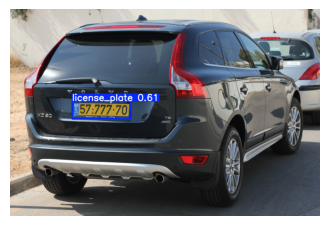

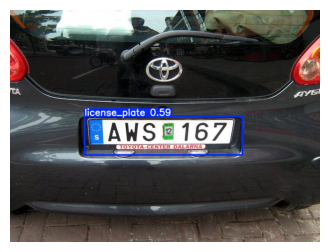

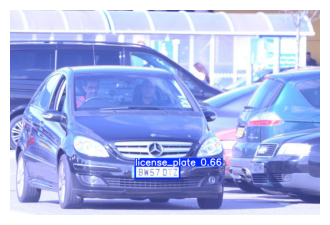

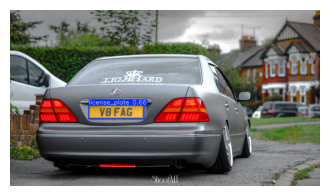

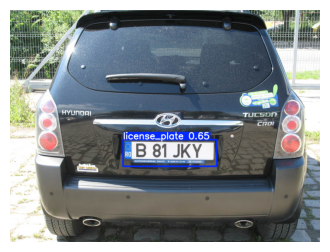

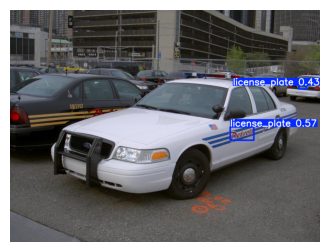

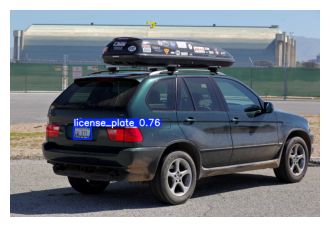

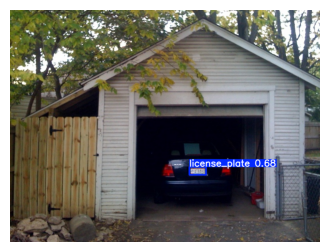

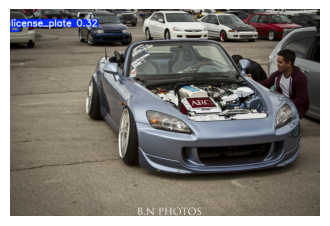

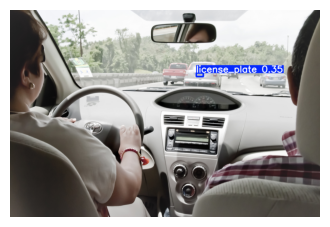

In [ ]:
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load trained model
model = YOLO("/kaggle/working/YOLO_Project/Run1/weights/best.pt")

# 2. Run prediction
results = model.predict(source=test_images, conf=0.25, verbose=False)

# Display all predicted images
for i in range(200,210):
    annotated_rgb = results[i].plot()[:, :, ::-1]   # BGR → RGB

    plt.figure(figsize=(4, 4))
    plt.imshow(annotated_rgb)
    plt.axis("off")
    plt.show()

Displaying: /kaggle/input/datasets/pankajkhanwariya5/image-data/images_zipped/images/test/003a5aaf6d17c917.jpg


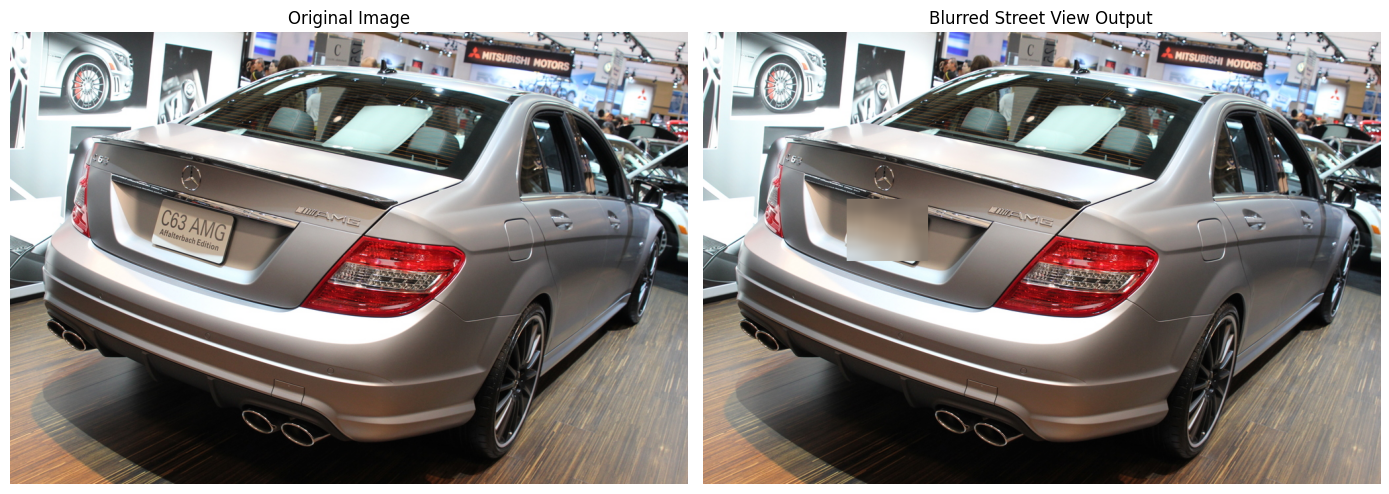

Displaying: /kaggle/input/datasets/pankajkhanwariya5/image-data/images_zipped/images/test/00723dac8201a83e.jpg


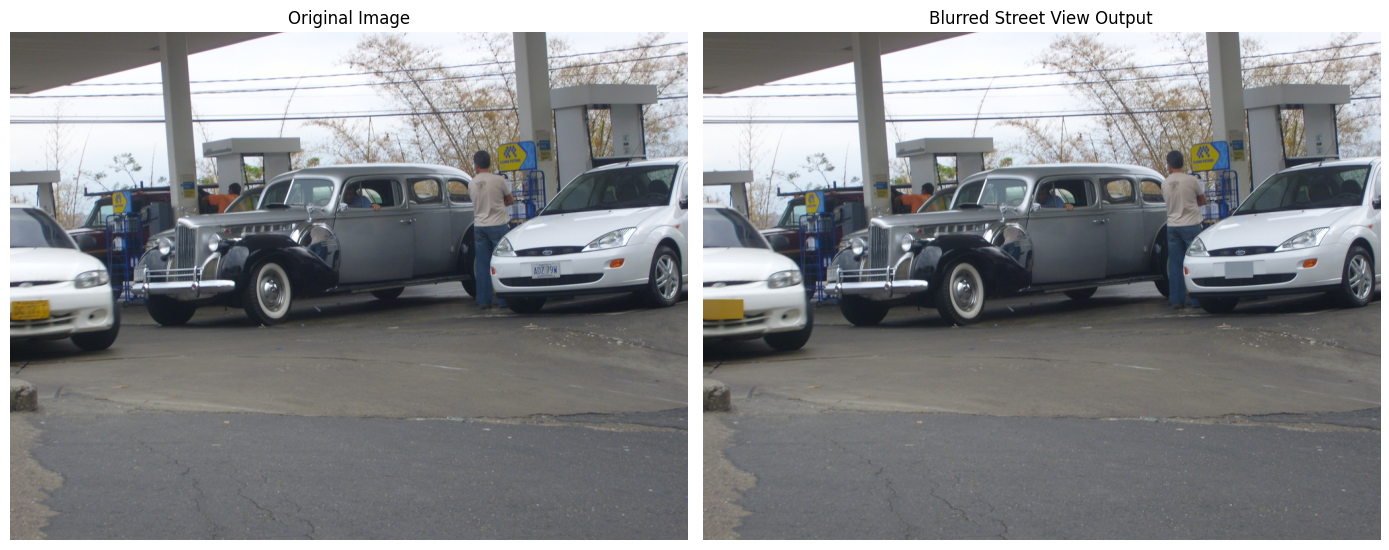

Displaying: /kaggle/input/datasets/pankajkhanwariya5/image-data/images_zipped/images/test/008637722500f239.jpg


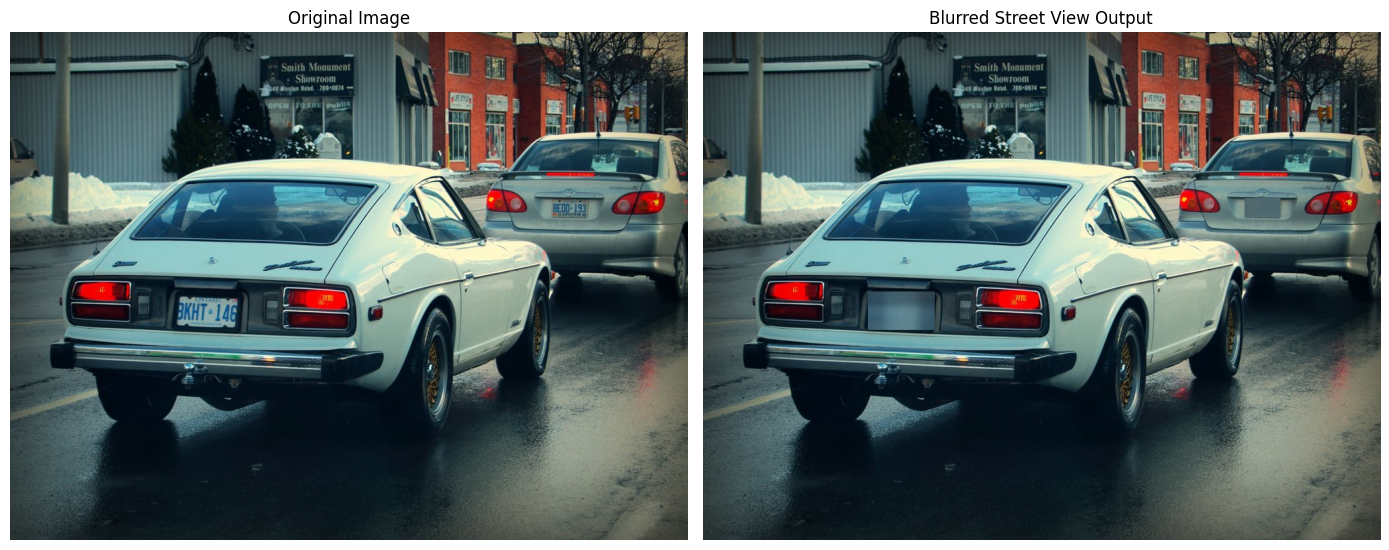

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO("/kaggle/working/YOLO_Project/Run1/weights/best.pt")

def show_blurred_result(img_path, conf_threshold=0.25):
    # Read original image
    img = cv2.imread(img_path)
    original_rgb = cv2.cvtColor(img.copy(), cv2.COLOR_BGR2RGB)

    # Run prediction
    results = model.predict(source=img, conf=conf_threshold, verbose=False)

    # Apply Gaussian blur to detected boxes
    for result in results:
        boxes = result.boxes.xyxy.cpu().numpy()
        for box in boxes:
            x1, y1, x2, y2 = map(int, box[:4])
            roi = img[y1:y2, x1:x2]
            if roi.size > 0:
                blurred_roi = cv2.GaussianBlur(roi, (51, 51), 30)
                img[y1:y2, x1:x2] = blurred_roi

    blurred_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Plot Side-by-Side Comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].imshow(original_rgb)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(blurred_rgb)
    axes[1].set_title("Blurred Street View Output")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Run visualization on a sample image
for img_path in test_images[:3]:
    print(f"Displaying: {img_path}")
    show_blurred_result(img_path)

# Answering questions here :

# Question 1 : How do you convert normalized YOLO bounding box coordinates (center_x, center_y, width, height) into pixel coordinates suitable for drawing rectangles with OpenCV?

##  Step 1 is Convert normalized values to pixels:

x_center = center_x * W

y_center = center_y * H

box_width = width * W

box_height = height * H

Where 'W' and 'H' are the image dimensions, for example 464 X 464 pixels

## Step 2 is Convert center coordinates to corner coordinates :

Open CV 'cv.rectangle()' needs

           (top-left x, top-left y)

           (bottom-right x, bottom-right y)

x1 = int(x_center - box_width/2)
y1 = int(y_center - box_height/2)

x2 = int(x_center + box_width/2)
y2 = int(y_center + box_height/2)           

## Step 3 is Drawing the rectangle

cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)

# Question 2: Write a function to overlay bounding boxes onto raw images. Why is this step critical before starting the training process?

(696, 1024, 3)


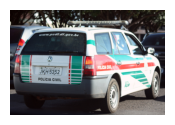

In [ ]:
img = plt.imread(train_images[1200])
plt.figure(figsize=(2,2))
plt.imshow(img)
plt.axis("off")
print(img.shape)

In [ ]:
image_path = train_images[1200]
label_path = image_path.replace("/images/", "/labels/").replace(".jpg", ".txt") # reading here the same label that corresponds to same image

with open(label_path) as f:
    label = f.readline().strip()

class_id, cx, cy, bw, bh = map(float, label.split())
# class id, center of the box x, center of the box y, width of the box, height of the box

In [ ]:
import cv2

def draw_bbox(image, x1, y1, x2, y2):

    image = image.copy()

    cv2.rectangle(
        image,
        (x1, y1),      # Top-left corner
        (x2, y2),      # Bottom-right corner
        (0,255,0),     # Green color
        2              # Thickness
    )

    return image

In [ ]:
H, W = img.shape[:2]

x_center = cx * W
y_center = cy * H
box_width = bw * W
box_height = bh * H

x1 = int(x_center - box_width/2)
y1 = int(y_center - box_height/2)
x2 = int(x_center + box_width/2)
y2 = int(y_center + box_height/2)

image = draw_bbox(img, x1, y1, x2, y2)

## Before training, we overlay bounding boxes to verify annotation quality.

It helps us identify:

 Bounding box correctly covers the license plate.

 Image and label are correctly matched.

 No missing or incorrect annotations.

 Normalized YOLO coordinates are converted correctly.

 No corrupted or shifted labels.

If annotations are wrong, the model learns incorrect object locations, resulting in poor detection performance regardless of the model architecture.

# Question 3: How did annotation quality impact the final blurring accuracy?

Annotations has direct impact on the final blurring accuracy because YOLO v8 learns object detections  entirely from the annotated bounded boxes.

In this case study:

1. Accurate annotations → YOLO precisely detected the license plate, resulting in correct and complete blurring.

2. Incorrect or shifted annotations → YOLO learned incorrect locations, causing partial blurring, misplaced blur, or missed license plates.

3. Missing annotations → The model treated those license plates as background and failed to detect them.

4. Duplicate or noisy annotations → Increased training noise, reducing Precision and mAP.

# Question 4: How did you preprocess images before feeding them into YOLOv8 without losing fine-grained plate details?

I performed minimal preprocessing because YOLOv8 has a built-in preprocessing pipeline.

1. Validated image–label pairs to remove unmatched files.

2. Verified annotations by overlaying bounding boxes on sample images.

3. Kept original image quality; no manual resizing or cropping was performed.

4. Set imgsz=640, allowing YOLOv8 to letterbox images (resize while preserving aspect ratio with padding), preventing distortion of license plates.

5. YOLOv8 automatically normalized images and applied augmentations (if enabled) during training.

# Question 5: Why did you choose YOLOv8 for license plate detection instead of a two-stage detector?

I chose YOLOv8 because the project required accurate and real-time license plate detection before applying blur.

1. Single-stage detector: YOLOv8 detects objects in one forward pass, making it significantly faster than two-stage detectors like Faster R-CNN.

2. Real-time performance: Lower inference latency makes it suitable for traffic surveillance and live video streams.

3. High accuracy for small objects: YOLOv8 has improved feature extraction and multi-scale detection, which helps detect relatively small license plates.

4. Easy deployment: It provides an end-to-end pipeline for training, validation, and inference with pretrained weights.

The main reason is that Two-stage detectors first generate region proposals and then classify them, making them more computationally expensive and slower. Since this project prioritizes real-time detection followed by immediate blurring, YOLOv8 offers a better balance between speed and accuracy.

# Question 6: Which YOLOv8 variant did you select, and how did it balance speed and accuracy for this use case?

I selected YOLOv8n (Nano) because it provides the best trade-off between speed and accuracy for this use case.

1. Pretrained model: Started with yolov8n.pt to leverage transfer learning and reduce training time.

2. Fast inference: Its lightweight architecture enables near real-time license plate detection, which is important before applying blur.

3. Good accuracy: Despite being the smallest YOLOv8 variant, it achieved satisfactory Precision, Recall, and mAP for license plate localization.

4. Resource-efficient(THE MAIN REASON FOR ME): It requires less GPU memory and trains faster, making it suitable for Google Colab and Kaggle GPUs (T4).

Adding to above, Larger models generally improve accuracy but require significantly more computation and training time. For this privacy-preservation application, YOLOv8n provided an optimal balance between detection accuracy, inference speed, and computational cost.

# Question 7: How did license plate characteristics influence your choice of model scale?

License plates are small, rectangular objects with fine details that may appear at different distances and viewing angles. This influenced my choice of YOLOv8n because:

1. Small object detection: YOLOv8n's multi-scale feature extraction is effective at detecting small objects like license plates.

2. Real-time requirement: The objective was to detect and blur plates quickly, so a lightweight model was preferred.

3. Resource constraints: The project was trained on Colab/Kaggle GPUs, where YOLOv8n offered faster training and inference with lower GPU memory usage.

4. Balanced performance: It provided sufficient detection accuracy while maintaining low latency, making it well-suited for this privacy-preservation application.

So, The small size of license plates required good small-object detection, while the need for real-time blurring and limited GPU resources made YOLOv8n the most suitable model scale.

# Question 8: How did you apply blurring only within the detected bounding box?

After YOLOv8 detected the license plate, it returned the bounding box coordinates (x1, y1, x2, y2).

1. Extracted only the Region of Interest (ROI):

In [ ]:
roi = image[y1:y2, x1:x2]

2. Applied Gaussian Blur to the ROI:

In [ ]:
blurred = cv2.GaussianBlur(roi, (31,31), 0)

3. Replaced the original ROI with the blurred ROI:

In [ ]:
image[y1:y2, x1:x2] = blurred

As a result, only the detected license plate was blurred, while the rest of the image remained unchanged.

## Adding to above, The other types of blurring are:

1. Average Blur (Box Blur): "Replaces each pixel with the average of neighboring pixels"

2. Gaussian Blur: "Uses a Gaussian (bell-shaped) weighted kernel, giving higher weight to closer pixels"

3. Median Blur: "Replaces the center pixel with the median of neighboring pixel values."

4. Bilateral Filter: "Smooths the image while preserving edges"